In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [3]:
from ast import Str


class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [4]:
def first_node(state: AgentState) -> AgentState:
    """this is the first node of a sequential graph"""

    state['final'] = f"Hi {state['name']}"
    return state

In [10]:
def second_node(state: AgentState) -> AgentState:
    """this is the second node of a sequential graph"""

    state['final'] = state["final"] + f" You are {state['age']} years old!"
    return state

In [11]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second", second_node)
graph.set_entry_point("first_node")
graph.set_finish_point("second")
graph.add_edge("first_node", "second")

app = graph.compile()

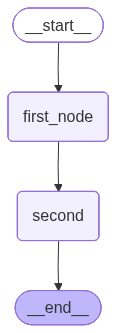

In [12]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
result = app.invoke({"name": "Dhruv", "age": "22"})
print(result)

{'name': 'Dhruv', 'age': '22', 'final': 'Hi Dhruv You are 22 years old!'}


In [14]:
print(result['final'])

Hi Dhruv You are 22 years old!
